## Formatting for Plots

In [64]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display, HTML

# Theme Setup
sns.set_theme(style="darkgrid", context="talk")

plt.rcParams.update({
    "figure.facecolor": "#1e1e1e",
    "axes.facecolor": "#1e1e1e",
    "axes.edgecolor": "#cccccc",
    "axes.labelcolor": "#e0e0e0",
    "text.color": "#e0e0e0",
    "xtick.color": "#cccccc",
    "ytick.color": "#cccccc",
    "grid.color": "#444444",
    "grid.alpha": 0.3,
    "legend.facecolor": "#2a2a2a",
    "legend.edgecolor": "#aaaaaa",
    "axes.titleweight": "bold",
    "font.family": "monospace",
    "font.size": 12,
    "savefig.facecolor": "#1e1e1e"
})

# CSS for widgets
display(HTML("""
<style>
.output_area, .jupyter-widgets, .widgets-vbox, .widgets-hbox, .p-Widget {
    background-color: #1e1e1e !important; border: none !important;
}
.dark-slider .widget-label { color: #e0e0e0 !important;
                            font-size: 18px !important;
                            font-family: monospace !important;
                            font-weight: bold !important; }
.dark-slider .widget-readout { color: #e0e0e0 !important; font-family: monospace !important; font-size: 18px !important; font-weight: bold !important; }
.dark-slider .noUi-target { background: #2a2a2a !important; border: none !important; }
.dark-slider .noUi-connect { background: #4dabf7 !important; }
.dark-slider .noUi-handle { background: #cccccc !important; border: none !important; }
.dark-slider .noUi-handle:hover { background: #ffffff !important; }
img { background-color: #1e1e1e !important; }
</style>
"""))

## SDSS Analysis Part 0: Assumed Knowledge

While this data analysis is meant for the public, it still requires the reader to have some basic science knowledge:

* You should know that light comes in the form of photons, but can also be described in terms of a wave that can have different wavelengths, which determines the colour of objects
* You should be comfortable with using some basic astronomy terms, like "stars" and "galaxies"
* You should be familiar with basic scientific and academic terminology, like "machine learning", "graphs", "telescope" and "relationship"

## SDSS Analysis Part 1: Introduction

<br>

<div style="width: 1200px">
<center>
<span style="
border: 2px solid #DDDDDD;
padding: 15px;
font-size: 20px;
font-style: italic;">
"What drives galaxy transformation, and can we predict where a galaxy is in its evolutionary lifecycle?"</span>
</center>

<br>

In this Jupyter notebook, we’ll explore this question using real astronomical data from the Sloan Digital Sky Survey (SDSS-V, Data Release 19 [July 2025]). This dataset contains detailed measurements of millions of different celestial objects, including their positions, brightness, and colour.

Through a combination of interactive visualisations, graphs, and machine learning models, we will investigate key aspects of galaxies and their evolution, including:

* Colour bimodality: Why are some galaxies are blue and star-forming while others are red and passive?
* Size, shape, and structure: How do physical characteristics relate to evolution?
* Distances and luminosities: How can we trace galaxies across space and time?
* The Tolman test: Looking at cosmic expansion and surface brightness
* Predicting galaxy colour class: Using ML to classify galaxies
* Predicting redshift: Using ML to estimate galaxy distances
* Lifecycle positioning: Integrating all information to place galaxies in their evolutionary context

By the end of this notebook, you’ll not only see the universe as a vast collection of objects, but also begin to understand the processes shaping galaxies over cosmic history, and how we can use data to predict where a galaxy is in its lifecycle.

<center><img width=500px src="hst_galaxies.jpg"></img>

<i>Credit: ESA/Hubble & NASA, F. Pacaud, D. Coe</i></center>
</div>

### What is the SDSS?

<div style="
display: inline-block;
width: 650px;
margin-right: 100px">
The Sloan Digital Sky Survey (SDSS) is one of the most influential astronomical surveys ever conducted, designed to systematically map large portions of the night sky. Since it began in 2000, it has been carried out by an international collaboration of scientists using a dedicated telescope, producing one of the most comprehensive public datasets in astronomy.<br>

Over time, the SDSS has observed millions of celestial objects, including stars, galaxies, and extremely distant quasars, creating a structured dataset that underpins thousands of scientific studies.<br>

In this project, the SDSS dataset will help us identify patterns and relationships between the properties of celestial objects like colour, distance, and structure. In turn, this will allow us to investigate the physical processes that drive how galaxies form, evolve, and change over time.<br>
</div>

<div style="
display: inline-block;
width: 400px;">
<img src="sdss_telescope.jpg"></img>
<center><i>Credit: Patrick Gaulme</i></center>
</div>


### How does the SDSS Telescope Work?

The SDSS telescope collects data about the night sky in 2 main ways:

#### **Photometry**:

<div style="width: 1200px">

Photometry is the *process of measuring how bright an object appears in different light wavelengths.*

Instead of capturing just one image, the SDSS telescope observes every object through a set of filters (called `u`, `g`, `r`, `i`, and `z`), each corresponding to a different part of the spectrum, from ultraviolet to infrared.

Each filter tells us how much light the object emits in that range. When we compare these measurements, we get the object’s colour.

This is really useful. For example:

* Blue objects tend to be hotter and actively forming stars
* Red objects are often older or more evolved

<br>

<center>
<div style="width: 800px">
<img src="em_spectrum.png"></img>
</div>
</center>

<center><i>Credit: Haylam Yuen</i></center>
</div>

#### **Spectroscopy**:

<div style="
display: inline-block;
width: 600px;
margin-right: 30px">
While photometry gives us a broad overview, spectroscopy goes much deeper.<br>

A spectrograph takes incoming light and spreads it out into a continuous spectrum. But instead of being smooth, this spectrum contains dark and bright lines.

Each chemical element (like hydrogen, oxygen, or iron) interacts with light at very specific wavelengths, leaving behind a unique pattern.

Therefore, by looking at the spectroscopy of an image, we can find which wavelengths were emmited by different celestial objects, and from this we can we can determine several things, including:

* The chemical composition of the object (i.e. what elements are present)
* What kind of galaxy or star we are looking at (e.g. red dwarf vs brown dwarf)
* How old the object is, and how it was created


</div>

<div style="
display: inline-block;
width: 550px;">
<img src="spectra_emission.png"></img>

<center><i>Credit: NASA</i></center>
</div>

### What is Redshift?


<div style="width: 1200px">

<center>
<img src="redshift_diagram.jpg" width=550px></img>

<i>Credit: Bartleby</i>
</center>

<br>

As the universe expands, light stretches as it travels through space, because of an interesting phenomenon called the [doppler effect](https://en.wikipedia.org/wiki/Doppler_effect).

When a celestial object is moving **away** relatively from the earth, each photon takes longer to get to earth, so the percieved wavelength of the light is stretched out to the red end of the spectrum. This is called **redshift**.

Conversely, when a celestial object is moving **towards** the earth, each photon takes less time to get to earth, so the percieved wavelength of the light is condensed to the blue end of the spectrum, resulting in a phenomenon called **blueshift**.

Usually, the bigger the redshift, the further away the object is. Also, because light takes time to travel (photons zoom around at almost 300,000 kilometres per second), when we observe something 5 [light years](https://en.wikipedia.org/wiki/Light-year) away, we are actually seeing the object how it was 5 years ago, since the light takes 5 years to travel to earth. This means that high redshift also corresponds to objects that are further back in time. As we'll see later, this redshift is super useful, because it lets us figure out how old certain objects are, and lets us essentially glimpse into how the universe was at the very beginning,

Here is an interactive plot in which you can simulate how redshift impacts the observed colour of objects:
</div>

In [65]:
# Data Preparation
wavelength = np.linspace(400, 1000, 1000)

# Gaussian function to simulate spectral lines
def gaussian(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2 * sigma**2))

original_line_center = 656.28  # H-alpha line in nm
original_spectrum = gaussian(wavelength, original_line_center, 6)

# Plotting Function
def plot_redshift(z):
    fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1e1e1e')
    ax.set_facecolor('#1e1e1e')
    
    # Redshift calculation
    shifted_center = original_line_center * (1 + z)
    shifted_wavelength = wavelength * (1 + z)
    
    # Original vs shifted spectrum
    ax.plot(wavelength, original_spectrum, '--', linewidth=1.5, alpha=0.3, color="#4dabf7", label="Original Wavelength")
    ax.plot(shifted_wavelength, original_spectrum, linewidth=3, color="#ff7043", label=f"Redshifted (z={z:.2f})")
    ax.fill_between(shifted_wavelength, original_spectrum, color="#ff7043", alpha=0.1)
    
    # Peak label
    ax.text(shifted_center, 1.1, f"{shifted_center:.1f} nm", color="#ff7043", ha='center', fontweight='bold', fontsize=10)
    
    # Styling
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity")
    ax.set_title("Redshift effect on spectral lines", color="#ffffff", loc='left', pad=20)
    ax.tick_params(colors='#cccccc')
    ax.grid(True, linestyle=':', alpha=0.2, color='#ffffff')
    ax.set_xlim(300, 1800)
    ax.set_ylim(0, 1.3)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')
    ax.legend(facecolor='#1e1e1e', edgecolor='#444444', labelcolor='#e0e0e0')
    
    plt.show()

# Widget Setup
z_slider = widgets.FloatSlider(value=0.0, min=0.0, max=1.5, step=0.01,
                               description='Redshift',
                               continuous_update=True,
                               layout=widgets.Layout(width='80%', margin='10px 0'))
z_slider.add_class("dark-slider")

ui = widgets.VBox([z_slider])
ui.layout = widgets.Layout(display='flex', align_items='center', width='100%', padding='20px 0')
out = widgets.interactive_output(plot_redshift, {'z': z_slider})

display(ui, out)

Output()

### What kinds of objects are we looking at in the dataset?

<div style="
display: inline-block;
width: 1200px">
Before we start analysing galaxies, it’s important to understand what kinds of objects we’re actually looking at. The SDSS dataset includes several different types of astronomical objects, each with very different physical properties.

<br>

Every object in the dataset is classified into one of three main categories:

<br>

* **STARS**:

&emsp; &emsp; - Stars are individual points of light located within the Milky Way

&emsp; &emsp; - They are relatively close by on cosmic scales

&emsp; &emsp; - They appear as point sources (no visible structure)

&emsp; &emsp; - Their light comes from nuclear fusion happening in their cores

&emsp; In this dataset, stars are not part of the distant universe we’re primarily interested in, but they’re important for comparison and calibration.

<br>

* **GALAXIES**:

&emsp; &emsp; - Galaxies are enormous systems made up of billins of stars, gas and dust, and dark matter

&emsp; &emsp; - Unlike stars, galaxies often appear extended (they have visible shape and structure)

&emsp; Galaxes are the main focus of this project because they evolve over time.

<br>

* **QUASI-STELLAR OBJECTS / QUASARS (QSOs)**:

&emsp; &emsp; - Quasars (QSOs) are among the brightest objects in the universe

&emsp; &emsp; - They are powered by matter falling into a supermassive black hole at the centre of a galaxy

&emsp; &emsp; - QSOs are often located at very large distances

&emsp; &emsp; - They appear point-like (similar to stars), but are fundamentally different from stars
</div>

### First Look at the data:

Now that we've covered the most important theoretical topics that you should know, it's time to actually start looking at our data!

We'll start by loading in our data using a Python library called **Pandas**. This data is called `SDSS_500k_v3.csv` and it's in the form of a CSV (Comma Separated Values), which you can think of like a Microsoft Excel table.

In [66]:
import pandas as pd

df = pd.read_csv("SDSS_500k_v3.csv")

Now let's have a quick look to see what kind of data we're dealing with by having a look at the first 5 rows of the dataset. Here, each row represents 1 celestial object, like a start or a galaxy, while each column is a certain *feature* or *attribute* of the object, such as its ID or redshift:

In [67]:
print(df.head())

                 objid         ra       dec         u         g         r  \
0  1237645942905635109  57.487019  0.099162  24.10896  21.27812  19.37220   
1  1237645942906028225  58.362510  0.056987  21.90226  19.58863  18.29155   
2  1237645942906290775  58.923318  0.051249  23.43689  22.50598  20.85043   
3  1237645943976493336  50.769166  0.913952  21.68376  20.73184  20.04118   
4  1237645943978328381  54.960577  0.915552  23.14064  21.99405  20.13622   

          i         z            specobjid   class  zWarning  redshift  \
0  18.63174  18.16487  1399624750124263424  GALAXY         0  0.327285   
1  17.67697  17.23689  1398542555318085632  GALAXY         0  0.169831   
2  20.05530  19.59501  1399665432054491136  GALAXY         0  0.317386   
3  19.81058  19.53287   801755119774361600  GALAXY         0  0.310486   
4  19.40749  18.98003  2972476440009875456  GALAXY         0  0.406500   

             flags  petroRad_r  petroMag_r  expRad_r  deVRad_r  fracDeV_r  \
0  105622104310

Woah! This is a lot of attributes, so let's just isolate the feature names and list them out to see what each of them tell us:

In [68]:
print(df.columns)

Index(['objid', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'specobjid', 'class',
       'zWarning', 'redshift', 'flags', 'petroRad_r', 'petroMag_r', 'expRad_r',
       'deVRad_r', 'fracDeV_r', 'expAB_r', 'deVAB_r'],
      dtype='str')



<div style="
display: inline-block;
width: 1200px;">

**OBJID**: This is a unique identifier based on the **photometric data** that will allow us to cross-reference the celestial object with other information online

**SpecOBJID**: This is also a unique identifier, but this time it is based on the **spectroscopic data**

**Ra & Dec**: Right Ascension and Declination tell us in which part of the sky the object is by giving us the angle from the [vernal equinox](https://en.wikipedia.org/wiki/March_equinox) and the [celestial equator](https://en.wikipedia.org/wiki/Celestial_equator):

<center>
<img width=300px src="ra_dec.jpg"></img>

<i>Credit: Bob King</i>
</center>

`u`, `g`, `r`, `i`, `z`: The amount of ultraviolet, green, red, infrared and mid-infrared wavelength light coming from the celestial object, respectively

</div>

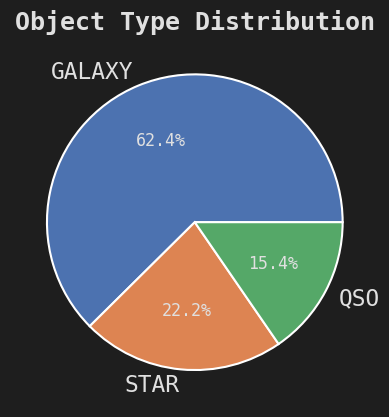

In [69]:
df['class'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Object Type Distribution")
plt.ylabel("")
plt.show()

## SDSS Analysis Part 2: Data Splitting

Now, a small 5% portion of the subset will be placed aside as a test set to validate the accuracy of the ML model:

In [70]:
from sklearn.model_selection import train_test_split

stratified_train_set, stratified_test_set = train_test_split(df_non_stratified, test_size=0.05, stratify=df_non_stratified["class"], random_state=67)

print(stratified_train_set["class"].value_counts() / len(stratified_train_set))
print("")
print(stratified_test_set["class"].value_counts() / len(stratified_test_set))

df = stratified_train_set.copy()

class
GALAXY    0.603486
STAR      0.235752
QSO       0.160762
Name: count, dtype: float64

class
GALAXY    0.60348
STAR      0.23576
QSO       0.16076
Name: count, dtype: float64


## SDSS Analysis Part 3: 